In [45]:
%load_ext autoreload
%autoreload 2

# Optional: import common packages
import numpy as np
import matplotlib.pyplot as plt
# x = [0,  1,    2]
# y = [0., 1, 0]
periodic = False



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [46]:
def F110():
    lf = 0.15875			# front tyres from center of gravity [m]
    lr = 0.17145			# read tyres from center of gravity [m]
    mass = 3.74 			# vehicle mass [kg]
    Iz = 0.04712 			# moment of inertia [kgm^2]
    hcog = 0.074
    mu = 0.523
    min_v = -1.0
    max_v = 20.
    switch_v = 1.
    max_acc = 9.51 			# max acceleration [m/s^2]
    min_acc = -13.26 		# max deceleration [m/s^2]
    max_steer = 0.34 		# max steering angle [rad]
    min_steer = -0.34 	# min steering angle [rad]
    max_steer_vel = 3.2 	# max steering velocity [rad/s]
    

    # rw = .047
    #mw = 0.055
    # r_Iw = .043
    mw = 0.1
    rw = .051
    r_Iw = .043

    poles = 4
    gear_ratio = 11.82
    lam = .000726
    Rs = .00954

    Iw = 0.9 * mw * r_Iw * r_Iw

    max_jerk = 10
    min_jerk = -10

    max_inputs = [max_acc, max_steer]
    min_inputs = [min_acc, min_steer]

    max_rates = [None, max_steer_vel]
    min_rates = [None, -max_steer_vel]	

    params = {
        'lf': lf,
        'lr': lr,
        'mass': mass,
        'Iz': Iz,
        'h': hcog,
        'mu': mu,
        'min_v': min_v,
        'max_v': max_v,
        'switch_v': switch_v,
        'max_acc': max_acc,
        'min_acc': min_acc,
        'max_steer': max_steer,
        'min_steer': min_steer,
        'max_steer_vel': max_steer_vel,
        'min_jerk': min_jerk,
        'max_jerk': max_jerk,
        'max_inputs': max_inputs,
        'min_inputs': min_inputs,
        'max_rates': max_rates,
        'min_rates': min_rates,
        'rw': rw,
        'Iw': Iw,
        'pole_pairs': poles/2,
        'gear_ratio': gear_ratio,
        'lambda':lam,
        'Rs': Rs,
        }
    return params

car_params = F110()

In [47]:
from scipy.interpolate import splev, splprep
import numpy as np


def generate_spline(x, y, wrap=False, plot_path=False, vel=1.0,
                    mus=None, Dfs=None,
                    g=9.81, safety=1):
    """
    Generate a spline path with a speed profile.

    Backward-compatible single-profile mode (default):
        returns (x_smooth, y_smooth, speeds_masked, tangents)

    Friction-bank mode (pass `mus` OR `Dfs`):
        builds one friction-limited speed profile per mu and
        returns (x_smooth, y_smooth, vs_masked, tangents, mus_resolved)
        where vs_masked has shape (num_mus, 500).
    """
    import matplotlib.pyplot as plt

    x = np.array(x)
    y = np.array(y)
    tck, u = splprep([x, y], s=0, per=wrap)
    u_fine = np.linspace(0, 1, 500)
    x_smooth, y_smooth = splev(u_fine, tck)
    dx_dt, dy_dt = splev(u_fine, tck, der=1)
    d2x_dt2, d2y_dt2 = splev(u_fine, tck, der=2)

    # Tangent angle at each point
    tangents = np.arctan2(dy_dt, dx_dt)
    curvature = np.abs(dx_dt * d2y_dt2 - dy_dt * d2x_dt2) / (dx_dt**2 + dy_dt**2)**1.5

    # ------------------------------------------------------------------
    # Resolve the friction axis. If Dfs given, convert to mu via Fz_f.
    #   Df = mu_f * Fz_f  ->  mu = Df / Fz_f,  Fz_f = m*g*lr/(lf+lr)
    # bank_mode is True whenever the caller asked for a sweep.
    # ------------------------------------------------------------------
    bank_mode = (mus is not None) or (Dfs is not None)
    if Dfs is not None and mus is None:
        if car_params is None:
            raise ValueError("car_params required to convert Dfs -> mus")
        m = car_params['mass']
        lf, lr = car_params['lf'], car_params['lr']
        Fz_f = m * g * lr / (lf + lr)
        mus_resolved = np.array([Df / Fz_f for Df in Dfs], dtype=float)
    elif mus is not None:
        mus_resolved = np.array(mus, dtype=float)
    else:
        mus_resolved = None  # single-profile mode

    # ------------------------------------------------------------------
    # Build the ramp multiplier (unchanged start/stop shaping).
    # ------------------------------------------------------------------
    velocity_multiplier = np.ones_like(u_fine)
    if not wrap:
        ramp_fraction = 0.2
        ramp_up_mask = u_fine < ramp_fraction
        velocity_multiplier[ramp_up_mask] = .5 + .5 * (1 - np.cos(np.pi * u_fine[ramp_up_mask] / ramp_fraction))

        ramp_fraction = 0.1
        ramp_down_mask = u_fine > (1 - ramp_fraction)
        velocity_multiplier[ramp_down_mask] = 0.5 * (1 + np.cos(np.pi * (u_fine[ramp_down_mask] - (1 - ramp_fraction)) / ramp_fraction))

    # ------------------------------------------------------------------
    # Speed profile(s).
    # ------------------------------------------------------------------
    curvature_safe = np.maximum(curvature, 1e-4)  # avoid div-by-zero on straights

    if bank_mode:
        # Constant velocity per mu (curvature-independent). The flat speed scales
        # linearly with mu: half of `vel` at mu=0, full `vel` at mu=1.
        vs = []
        vs_masked = []
        for mu in mus_resolved:
            scale = 0.75 + 0.25 * np.clip(mu, 0.0, 1.0)   # 0.75 at mu=0, 1.0 at mu=1
            v_const = scale * vel
            speeds_mu = np.full_like(u_fine, v_const)
            vs.append(speeds_mu)
            vs_masked.append(speeds_mu * velocity_multiplier)
        vs = np.array(vs)                # (num_mus, 500)
        vs_masked = np.array(vs_masked)  # (num_mus, 500)
    else:
        # Original single-profile behavior (flat vel, kept intact).
        steering_angle_deg = np.degrees(curvature)
        angle_points = [0, 20, 40, 90]
        if vel == 0:
            speed_points = [1.0, 1.0, 1.0, 1.0]
        else:
            speed_points = [vel, vel, vel, vel]
        speeds = np.interp(steering_angle_deg, angle_points, speed_points)
        speeds_masked = speeds * velocity_multiplier

    # ------------------------------------------------------------------
    # Plotting.
    # ------------------------------------------------------------------
    if plot_path:
        # Evaluate derivatives at original waypoint parameters for tangents
        dx_orig, dy_orig = splev(u, tck, der=1)
        tangent_angles_orig = np.arctan2(dy_orig, dx_orig)
        arrow_scale = 0.1

        plt.figure(figsize=(5, 5))
        plt.plot(x, y, 'o', label='Original points')
        plt.plot(x_smooth, y_smooth, '-', label='Smooth spline')
        plt.quiver(
            x, y,
            np.cos(tangent_angles_orig), np.sin(tangent_angles_orig),
            scale=1/arrow_scale, scale_units='xy', angles='xy',
            color='lime', zorder=5, width=0.008,
            label='Tangents'
        )
        for i, (xi, yi) in enumerate(zip(x, y)):
            plt.annotate(
                f"{i}: ({xi:.2f}, {yi:.2f})",
                (xi, yi),
                textcoords="offset points",
                xytext=(6, 6),
                fontsize=8,
                color='black',
                zorder=6
            )
        plt.legend()

        fig, ax1 = plt.subplots(figsize=(8, 4))
        ax2 = ax1.twinx()
        ax1.set_xlabel('Spline parameter u')
        ax1.set_ylabel('Speed (m/s)', color='b')
        ax1.tick_params(axis='y', labelcolor='b')
        ax2.plot(u_fine, curvature, 'r--', label='Curvature (1/m)')
        ax2.set_ylabel('Curvature (1/m)', color='r')
        ax2.tick_params(axis='y', labelcolor='r')

        if bank_mode:
            # One masked speed curve per mu, colored by mu.
            cmap = plt.cm.viridis
            for k, mu in enumerate(mus_resolved):
                color = cmap(k / max(len(mus_resolved) - 1, 1))
                ax1.plot(u_fine, vs_masked[k], color=color,
                         label=f'mu={mu:.2f}')
            fig.suptitle('Friction-limited speed bank and curvature')
        else:
            ax3 = ax1.twinx()
            ax3.spines['right'].set_position(('outward', 60))
            ax1.plot(u_fine, speeds, 'b-', label='Speed (m/s)')
            ax3.plot(u_fine, speeds_masked, 'black', label='Speed masked')
            ax3.set_ylabel('Speed masked', color='black')
            ax3.tick_params(axis='y', labelcolor='black')
            fig.suptitle('Speed and Curvature along the Path')

        fig.tight_layout()
        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best')
        plt.show()

    # ------------------------------------------------------------------
    # Return.
    # ------------------------------------------------------------------
    if bank_mode:
        return x_smooth, y_smooth, vel, vs_masked, tangents, mus_resolved
    else:
        return x_smooth, y_smooth, speeds_masked, tangents

In [48]:
import os
def save_track(x_smooth, y_smooth, speeds_masked, tangents, track_name="test"):
    my_dict = {
        "x": x_smooth,
        "y": y_smooth,
        "speed": speeds_masked,
        "theta": tangents
    }
    np.savez(f"../tracks/{track_name}.npz", **my_dict)


def save_track_bank(x_smooth, y_smooth, v, vs_masked, mus, tangents, track_name="test"):
    my_dict = {
        "x": x_smooth,
        "y": y_smooth,
        "speed": v,
        "vs": vs_masked,      # (num_mus, 500)
        "mus": mus,           # (num_mus,)
        "theta": tangents,
    }
    path = os.path.abspath(f"../tracks/{track_name}.npz")
    print("Saving keys:", list(my_dict.keys()), "to", path)
    np.savez(f"../tracks/{track_name}.npz", **my_dict)

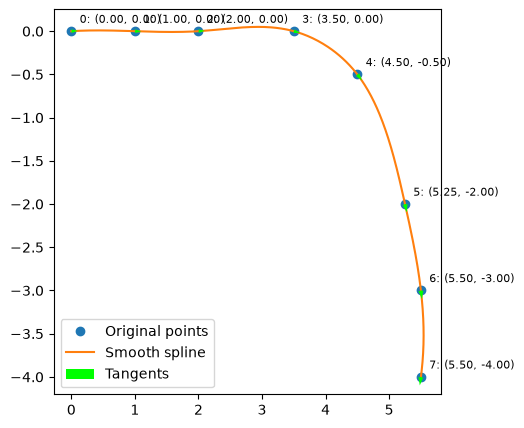

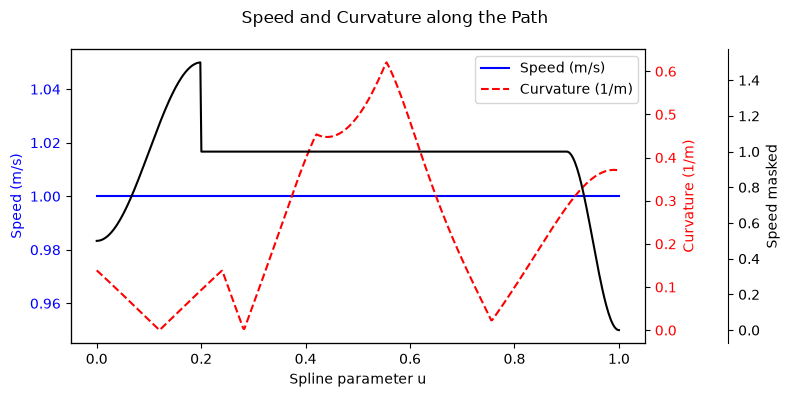

In [62]:
x = [0, 1, 2, 3.5, 4.5, 5.25, 5.5, 5.5]
y = [0, 0, 0, 0, -0.5, -2, -3, -4]
periodic = False
wrap = False
track_name = "blevel_turn_slow"
x_smooth, y_smooth, speeds_masked, thetas= generate_spline(
    x, y, wrap, plot_path = True, vel = 1.0)
save_track(x_smooth, y_smooth, speeds_masked, thetas, track_name)
# turn

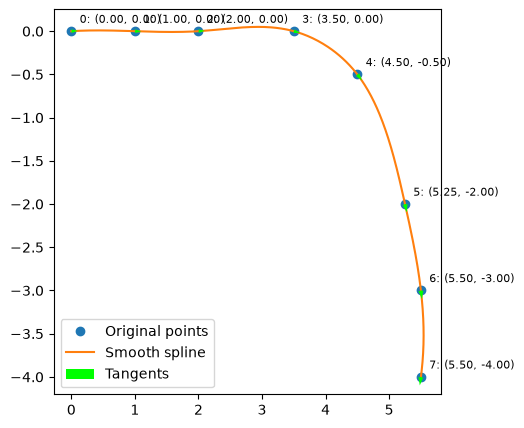

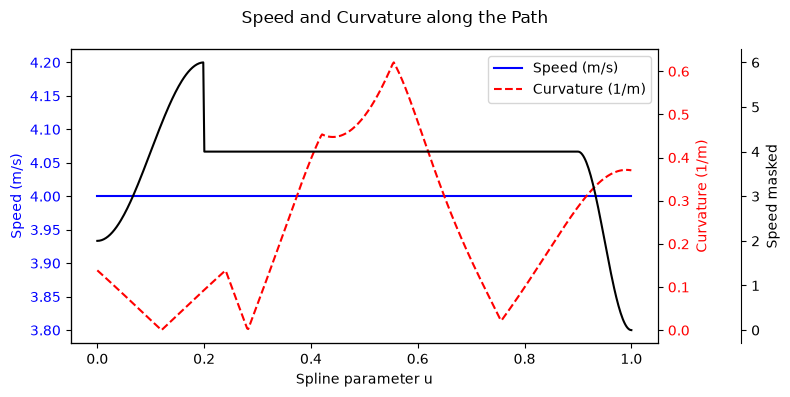

In [64]:
x = [0, 1, 2, 3.5, 4.5, 5.25, 5.5, 5.5]
y = [0, 0, 0, 0, -0.5, -2, -3, -4]
periodic = False
wrap = False
track_name = "blevel_turn_fast"
x_smooth, y_smooth, speeds_masked, thetas= generate_spline(
    x, y, wrap, plot_path = True, vel = 4)
save_track(x_smooth, y_smooth, speeds_masked, thetas, track_name)
# turn

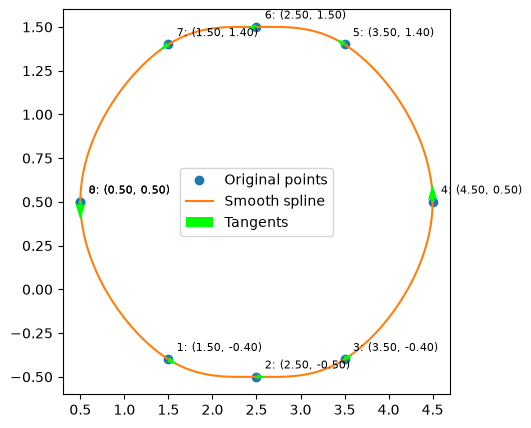

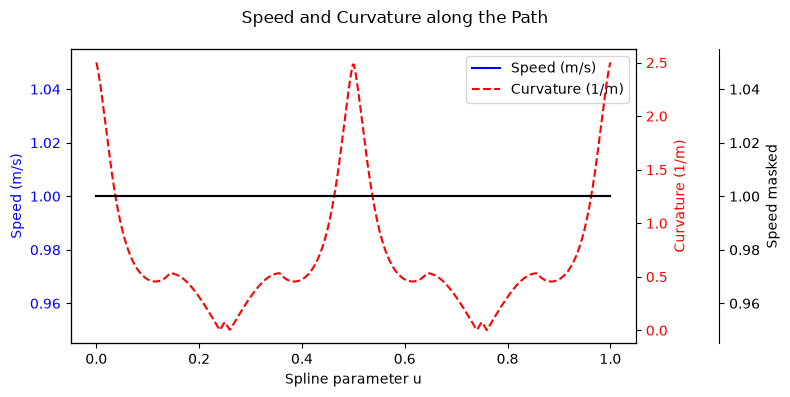

In [52]:
x = [0.5, 1.5,   2.5,  3.5, 4.5, 3.5, 2.5, 1.5, 0.5]
y = [0.5, -0.4, -0.5, -0.4, 0.5, 1.4, 1.5,  1.4, 0.5]
periodic = True
wrap = True
track_name = "blevel_ovalslow"
#circle
x_smooth, y_smooth, speeds_masked, thetas = generate_spline(
    x, y, wrap = True, plot_path = True, vel = 1.0)
save_track(x_smooth, y_smooth, speeds_masked, thetas, track_name)

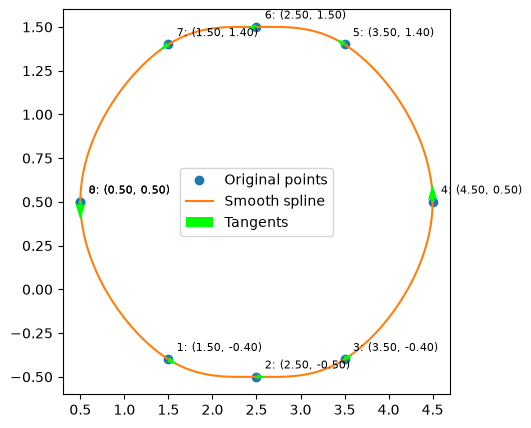

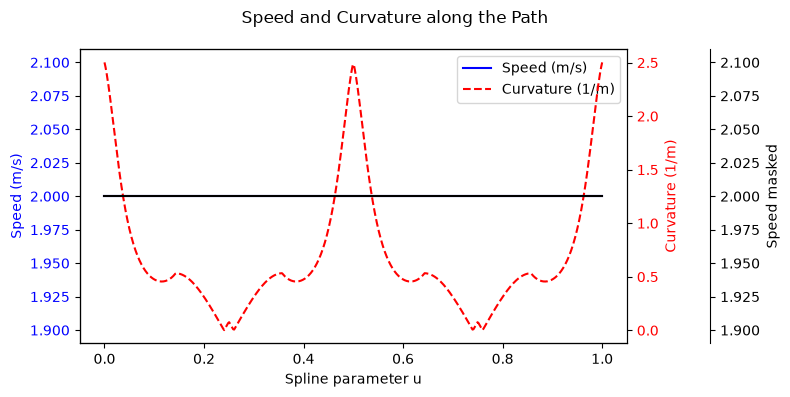

In [39]:
x = [0.5, 1.5,   2.5,  3.5, 4.5, 3.5, 2.5, 1.5, 0.5]
y = [0.5, -0.4, -0.5, -0.4, 0.5, 1.4, 1.5,  1.4, 0.5]
periodic = True
wrap = True
track_name = "blevel_ovalfast"
#circle
x_smooth, y_smooth, speeds_masked, thetas = generate_spline(
    x, y, wrap = True, plot_path = True, vel = 2.0)
save_track(x_smooth, y_smooth, speeds_masked, thetas, track_name)

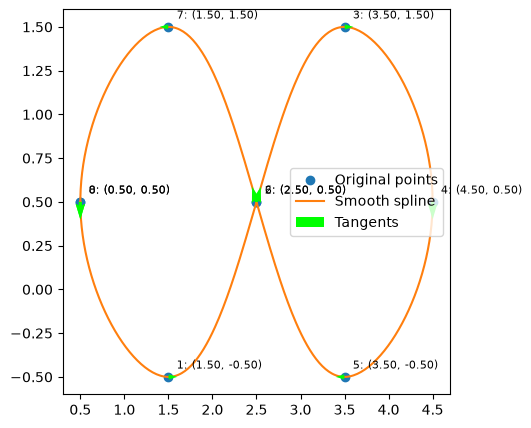

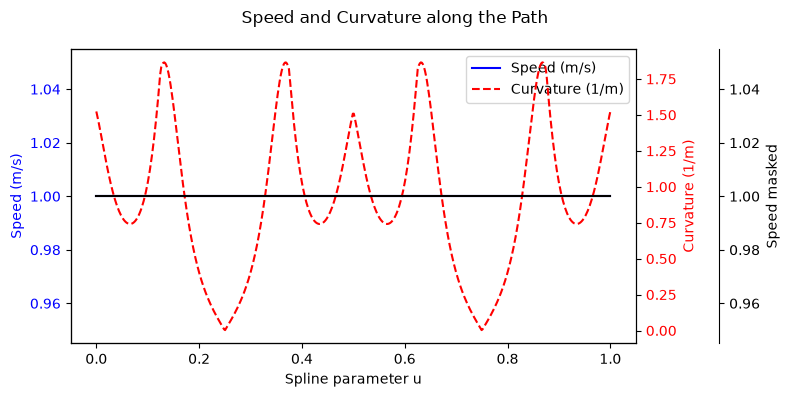

In [40]:
x = [0.5, 1.5,   2.5,  3.5, 4.5, 3.5, 2.5, 1.5, 0.5]
y = [0.5, -0.5, 0.5,  1.5, 0.5, -0.5, 0.5,  1.5, 0.5]
periodic = True
wrap = True
track_name = "blevel_fig8slow"
#circle
x_smooth, y_smooth, speeds_masked, thetas = generate_spline(
    x, y, wrap = True, plot_path = True, vel = 1.0)
save_track(x_smooth, y_smooth, speeds_masked, thetas, track_name)

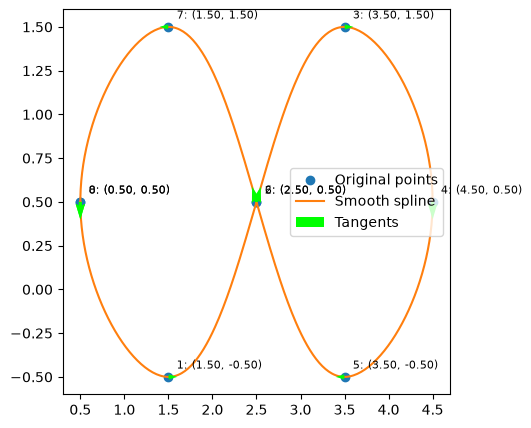

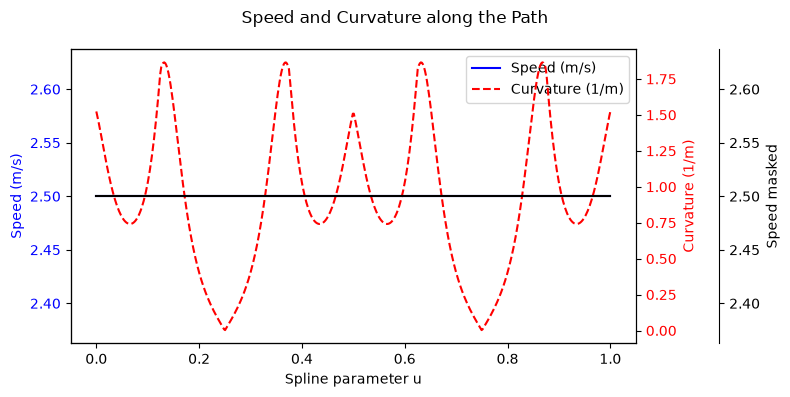

In [55]:
x = [0.5, 1.5,   2.5,  3.5, 4.5, 3.5, 2.5, 1.5, 0.5]
y = [0.5, -0.5, 0.5,  1.5, 0.5, -0.5, 0.5,  1.5, 0.5]
periodic = True
wrap = True
track_name = "blevel_fig8fast"
#circle
x_smooth, y_smooth, speeds_masked, thetas = generate_spline(
    x, y, wrap = True, plot_path = True, vel = 2.5)
save_track(x_smooth, y_smooth, speeds_masked, thetas, track_name)

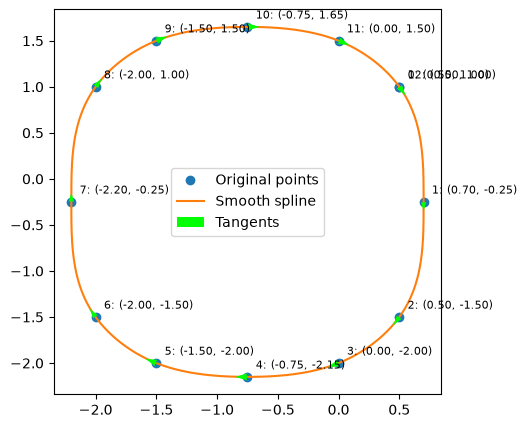

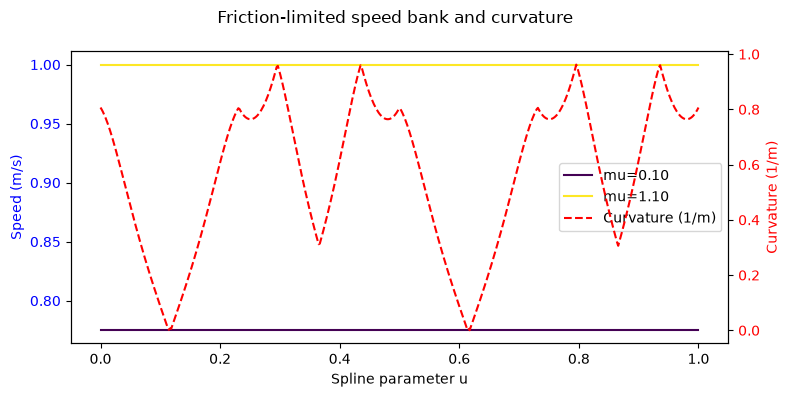

Saving keys: ['x', 'y', 'speed', 'vs', 'mus', 'theta'] to /home/henry/docker-workspace/src/llampc/llampc/utils/tracks/mocap_square2slow.npz


In [42]:
import numpy as np
x = [0.5, 0.7, 0.5, 0.0, -.75, -1.5,  -2.,  -2.2, -2., -1.5, -.75, 0.0, 0.5]
y = [1, -.25, -1.5, -2, -2.15,   -2, -1.5,  -.25, 1.0,   1.5, 1.65, 1.5, 1]
periodic = False
wrap = True
track_name = "mocap_square2slow"
mus = [0.1, 1.1]
x_smooth, y_smooth, vel, speeds_masked, thetas, mus = generate_spline(
    x, y, wrap = True, plot_path = True, vel = 1, mus = mus, safety = 1)
save_track_bank(x_smooth, y_smooth, vel, speeds_masked, mus, thetas, track_name)

# track oval

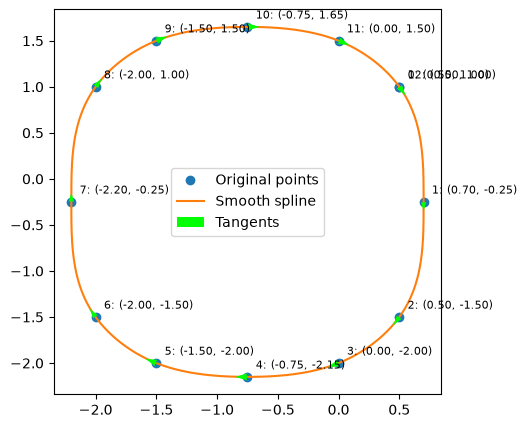

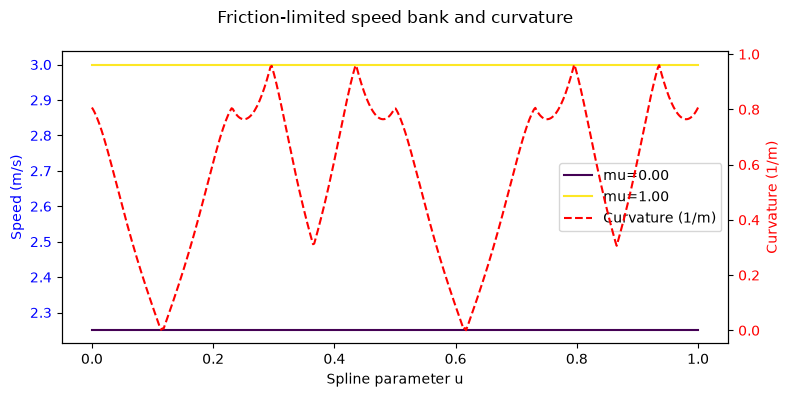

Saving keys: ['x', 'y', 'speed', 'vs', 'mus', 'theta'] to /home/henry/docker-workspace/src/llampc/llampc/utils/tracks/mocap_square2fast.npz


In [31]:
import numpy as np
x = [0.5, 0.7, 0.5, 0.0, -.75, -1.5,  -2.,  -2.2, -2., -1.5, -.75, 0.0, 0.5]
y = [1, -.25, -1.5, -2, -2.15,   -2, -1.5,  -.25, 1.0,   1.5, 1.65, 1.5, 1]
periodic = False
wrap = True
track_name = "mocap_square2fast"
mus = [0, 1]
x_smooth, y_smooth, vel, speeds_masked, thetas, mus = generate_spline(
    x, y, wrap = True, plot_path = True, vel = 3.0, mus = mus, safety = 1)
save_track_bank(x_smooth, y_smooth, vel, speeds_masked, mus, thetas, track_name)

# track oval

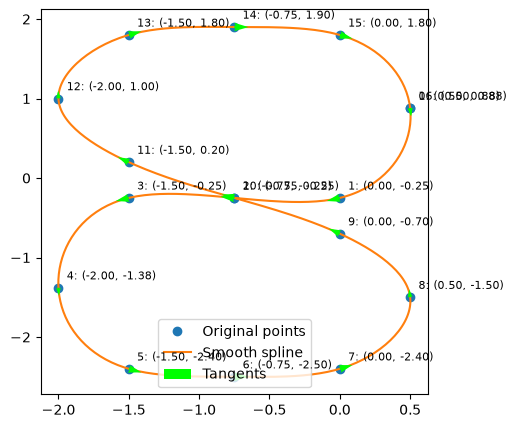

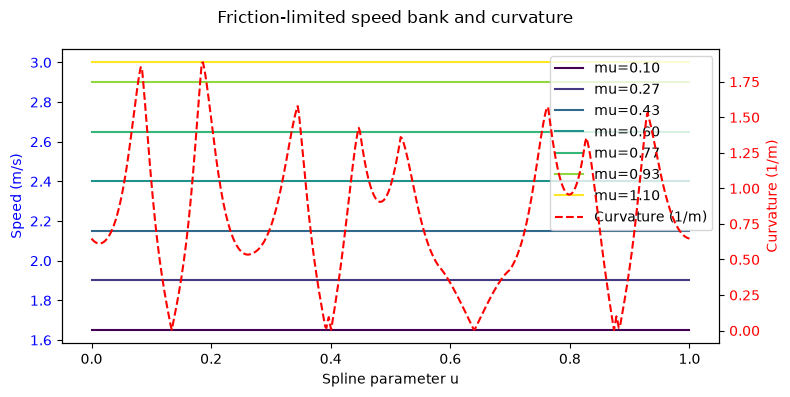

In [ ]:
import numpy as np
x = [0.5, 0,    -0.75, -1.5, -2.,  -1.5,   -.75,   0.0,  0.5,   0.0, -0.75, -1.5, -2., -1.5, -.75, 0.0, 0.5]
y = [0.88,-0.25, -.25, -.25, -1.38,  -2.4,  -2.5, -2.4, -1.5, -.7,  -.25,   0.2,  1.0,   1.8, 1.9, 1.8, 0.88]
periodic = False
wrap = True
mus = [0.1, .267, .433, 0.6,.767, .933, 1.1]
track_name = "mocap_fig8slow"
x_smooth, y_smooth, vel, vs, thetas, mus = generate_spline(
    x, y, wrap = True, plot_path = True, vel = 3, mus = mus, safety = 1)
save_track(x_smooth, y_smooth, speeds_masked, thetas, track_name)
# track oval

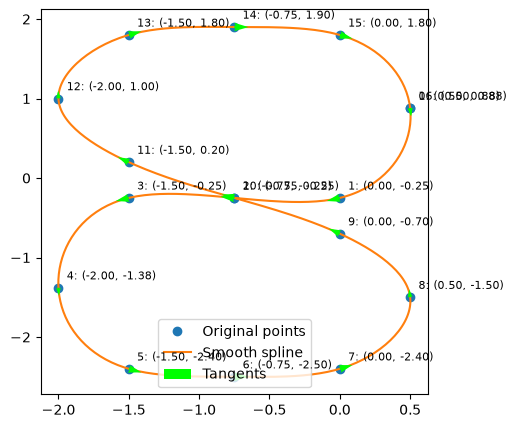

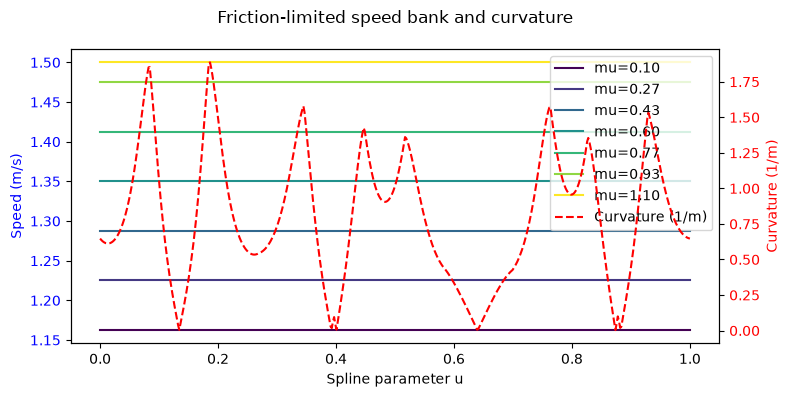

Saving keys: ['x', 'y', 'speed', 'vs', 'mus', 'theta'] to /home/henry/docker-workspace/src/llampc/llampc/utils/tracks/mocap_turnslowbank.npz


In [ ]:
import numpy as np
x = [0.5, 0,    -0.75, -1.5, -2.,  -1.5,   -.75,   0.0,  0.5,   0.0, -0.75, -1.5, -2., -1.5, -.75, 0.0, 0.5]
y = [0.88,-0.25, -.25, -.25, -1.38,  -2.4,  -2.5, -2.4, -1.5, -.7,  -.25,   0.2,  1.0,   1.8, 1.9, 1.8, 0.88]
periodic = False
wrap = True
track_name = "mocap_fig8slowbank"
mus = [0.1, .267, .433, 0.6,.767, .933, 1.1]
x_smooth, y_smooth, vel, speeds_masked, thetas, mus = generate_spline(
    x, y, wrap = True, plot_path = True, vel = 1, mus = mus)
save_track_bank(x_smooth, y_smooth, vel, speeds_masked, mus, thetas, track_name)


# track oval

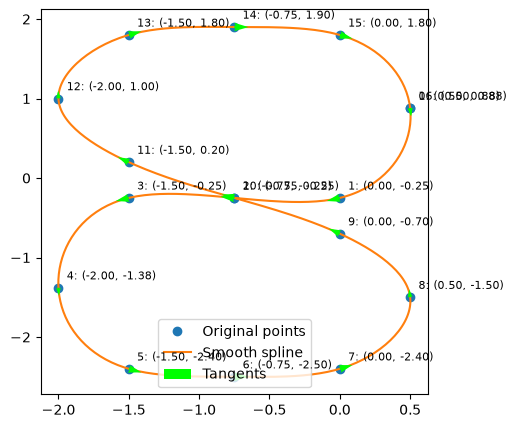

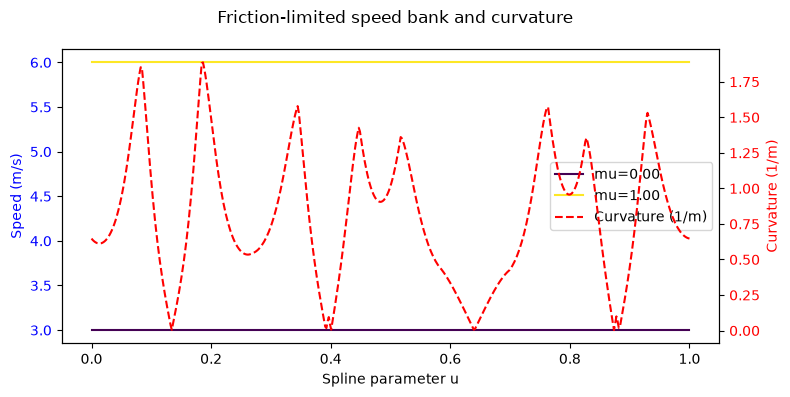

Saving keys: ['x', 'y', 'speed', 'vs', 'mus', 'theta'] to /home/henry/docker-workspace/src/llampc/llampc/utils/tracks/mocap_turnfastbank.npz


In [ ]:
import numpy as np
x = [0.5, 0,    -0.75, -1.5, -2.,  -1.5,   -.75,   0.0,  0.5,   0.0, -0.75, -1.5, -2., -1.5, -.75, 0.0, 0.5]
y = [0.88,-0.25, -.25, -.25, -1.38,  -2.4,  -2.5, -2.4, -1.5, -.7,  -.25,   0.2,  1.0,   1.8, 1.9, 1.8, 0.88]
periodic = False
wrap = True
track_name = "mocap_fig8fastbank"
mus = [0.0, 1.0]
x_smooth, y_smooth, vel, speeds_masked, thetas, mus = generate_spline(
    x, y, wrap = True, plot_path = True, vel = 2, mus = mus, safety = 1)
save_track_bank(x_smooth, y_smooth, vel, speeds_masked, mus, thetas, track_name)


# track oval

(500,)
(500,)
(500,)


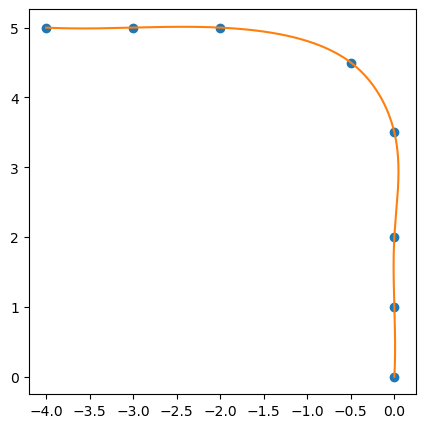

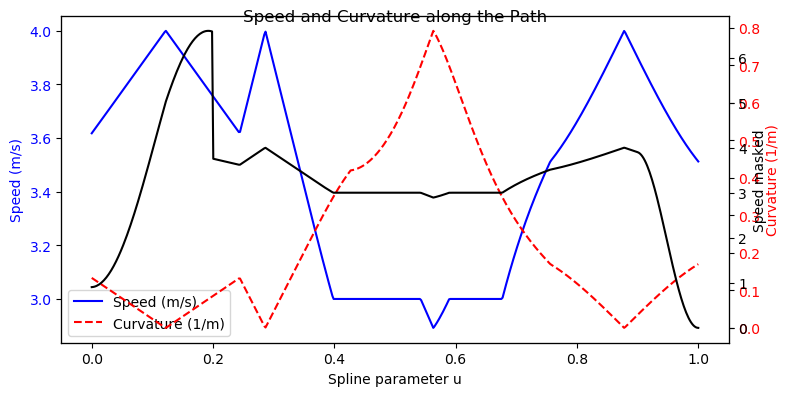